# Data Understanding — ISIC (2016–2024) + HAM10000

**Urutan kerjanya:** Setup → Verifikasi → Deskripsi → Skema Label → Eksplorasi (EDA) → Cek Kualitas → Deteksi Duplikat → Data Bersih & Before/After.
**Perlu diinget soal ISIC 2024:** didownload manual (bukan lewat `isic-cli`), jadi wajar gak punya `attribution.txt`/`licenses/` kayak source lain 

## Setup — Deteksi Dataset

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
from PIL import Image
from tqdm import tqdm

INPUT_ROOT = '/kaggle/input'

def find_dataset_roots_fast(input_root, name_contains=None, must_contain_any=None):
    """Cari folder dataset tanpa masuk ke folder gambar (biar cepat).
    Cek 2 pola: /kaggle/input/<slug> dan /kaggle/input/datasets/<user>/<slug>."""
    candidates = []
    for d in os.listdir(input_root):
        full = os.path.join(input_root, d)
        if os.path.isdir(full) and d != 'datasets':
            candidates.append(full)
    datasets_dir = os.path.join(input_root, 'datasets')
    if os.path.isdir(datasets_dir):
        for user in os.listdir(datasets_dir):
            user_path = os.path.join(datasets_dir, user)
            if os.path.isdir(user_path):
                for slug in os.listdir(user_path):
                    slug_path = os.path.join(user_path, slug)
                    if os.path.isdir(slug_path):
                        candidates.append(slug_path)
    matches = []
    for c in candidates:
        base = os.path.basename(c)
        if name_contains and name_contains.lower() in base.lower():
            matches.append(c)
            continue
        if must_contain_any:
            try:
                immediate_subdirs = [d.name for d in os.scandir(c) if d.is_dir()]
            except Exception:
                immediate_subdirs = []
            if any(x in immediate_subdirs for x in must_contain_any):
                matches.append(c)
    return matches

In [2]:
main_candidates = find_dataset_roots_fast(INPUT_ROOT, must_contain_any=['ham10000', 'isic_2016_train'])
isic2024_candidates = find_dataset_roots_fast(INPUT_ROOT, name_contains='2024')

main_dataset_root = main_candidates[0] if main_candidates else None
isic2024_dataset_root = isic2024_candidates[0] if isic2024_candidates else None

print("Main dataset root:", main_dataset_root)
print("ISIC 2024 dataset root:", isic2024_dataset_root)

Main dataset root: /kaggle/input/datasets/nadiraanindita/skin-lesion-data
ISIC 2024 dataset root: /kaggle/input/datasets/nadiraanindita/isic-2024-cancer-skin


In [3]:
source_registry = {}

if main_dataset_root:
    for d in os.listdir(main_dataset_root):
        full_path = os.path.join(main_dataset_root, d)
        if os.path.isdir(full_path):
            source_registry[d] = {'scan_root': full_path}

if isic2024_dataset_root:
    source_registry['isic_2024_train'] = {'scan_root': isic2024_dataset_root}

print(f"Total source terdaftar: {len(source_registry)}")
for name in source_registry:
    print(f"  - {name}")

Total source terdaftar: 14
  - isic_2018_val
  - isic_2020_train
  - ham10000
  - isic_2019_train
  - isic_2016_test
  - isic_2018_test
  - isic_2019_test
  - isic_2020_test
  - isic_2018_train
  - isic_2017_val
  - isic_2017_test
  - isic_2016_train
  - isic_2017_train
  - isic_2024_train


In [4]:
IMG_EXT = ('.jpg', '.jpeg', '.png')
all_images = []
sources = list(source_registry.keys())

for source, info in source_registry.items():
    count_before = len(all_images)
    for root, dirs, files in os.walk(info['scan_root']):
        for f in files:
            if f.lower().endswith(IMG_EXT):
                image_id = os.path.splitext(f)[0]
                all_images.append({'image_id': image_id, 'source': source, 'filepath': os.path.join(root, f)})
    print(f"{source}: {len(all_images) - count_before} gambar")

print(f"\nTotal semua source: {len(all_images)}")

isic_2018_val: 193 gambar
isic_2020_train: 33126 gambar
ham10000: 11720 gambar
isic_2019_train: 25331 gambar
isic_2016_test: 379 gambar
isic_2018_test: 1512 gambar
isic_2019_test: 8238 gambar
isic_2020_test: 10982 gambar
isic_2018_train: 10015 gambar
isic_2017_val: 150 gambar
isic_2017_test: 600 gambar
isic_2016_train: 900 gambar
isic_2017_train: 2000 gambar
isic_2024_train: 401059 gambar

Total semua source: 506205


In [5]:
df_images = pd.DataFrame(all_images)
df_images.head()

,image_id,source,filepath
0,ISIC_0034425,isic_2018_val,/kaggle/input/datasets/nadiraanindita/skin-les...
1,ISIC_0034431,isic_2018_val,/kaggle/input/datasets/nadiraanindita/skin-les...
2,ISIC_0034381,isic_2018_val,/kaggle/input/datasets/nadiraanindita/skin-les...
3,ISIC_0034485,isic_2018_val,/kaggle/input/datasets/nadiraanindita/skin-les...
4,ISIC_0034493,isic_2018_val,/kaggle/input/datasets/nadiraanindita/skin-les...


## Fase 1 — Verifikasi Data

Cek 3 file per source: metadata, jumlah gambar cocok sama metadata, dan gak ada file aneh.
*(`attribution.txt` & `licenses/` cuma dicek buat info, gak jadi syarat lolos — dataset yang didownload manual kayak ISIC 2024 emang wajar gak punya itu.)*

**1.1 — Cari & muat metadata tiap source**

In [6]:
def find_metadata_csv(scan_root):
    csv_found = []
    for root, dirs, files in os.walk(scan_root):
        for f in files:
            if f.lower().endswith('.csv'):
                csv_found.append(os.path.join(root, f))
    for f in csv_found:
        name = os.path.basename(f).lower()
        if 'metadata' in name or 'groundtruth' in name:
            return f
    return csv_found[0] if csv_found else None


metadata_dfs = {}
metadata_load_status = []

for source, info in source_registry.items():
    meta_path = find_metadata_csv(info['scan_root'])
    info['metadata_path'] = meta_path

    if meta_path is None:
        metadata_load_status.append({'Source': source, 'Metadata_File': None,
                                      'Status_Muat_Metadata': '❌ Tidak ada CSV ditemukan'})
        continue
    try:
        df_meta = pd.read_csv(meta_path, low_memory=False)
        metadata_dfs[source] = df_meta
        metadata_load_status.append({'Source': source, 'Metadata_File': os.path.basename(meta_path),
                                      'Status_Muat_Metadata': f'✅ Termuat ({len(df_meta)} baris)'})
    except Exception as e:
        metadata_load_status.append({'Source': source, 'Metadata_File': os.path.basename(meta_path),
                                      'Status_Muat_Metadata': f'❌ Gagal dibaca: {e}'})

df_metadata_load = pd.DataFrame(metadata_load_status)
df_metadata_load

,Source,Metadata_File,Status_Muat_Metadata
0,isic_2018_val,metadata.csv,✅ Termuat (193 baris)
1,isic_2020_train,metadata.csv,✅ Termuat (33126 baris)
2,ham10000,metadata.csv,✅ Termuat (11720 baris)
3,isic_2019_train,metadata.csv,✅ Termuat (25331 baris)
4,isic_2016_test,metadata.csv,✅ Termuat (379 baris)
5,isic_2018_test,metadata.csv,✅ Termuat (1512 baris)
6,isic_2019_test,metadata.csv,✅ Termuat (8238 baris)
7,isic_2020_test,metadata.csv,✅ Termuat (10982 baris)
8,isic_2018_train,metadata.csv,✅ Termuat (10015 baris)
9,isic_2017_val,metadata.csv,✅ Termuat (150 baris)


**1.2 — Klasifikasi semua file per source**

In [7]:
def classify_file(filepath, metadata_path_for_source):
    filename = os.path.basename(filepath)
    if filepath == metadata_path_for_source:
        return 'metadata'
    elif filename == 'attribution.txt':
        return 'attribution'
    elif filename.startswith('.isic-partial'):
        return 'partial (sisa download gagal)'
    elif filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        return 'gambar'
    elif filename.lower().endswith('.txt'):
        return 'license'
    elif filename.lower().endswith('.csv'):
        return 'csv_lain'
    else:
        return '❓ TIDAK DIKENALI'

file_classification = []
for source, info in source_registry.items():
    for root, dirs, files in os.walk(info['scan_root']):
        for f in files:
            fp = os.path.join(root, f)
            file_classification.append({'Source': source, 'Filename': f,
                                         'Kategori': classify_file(fp, info.get('metadata_path'))})

df_file_class = pd.DataFrame(file_classification)
df_klasifikasi_summary = df_file_class.groupby(['Source', 'Kategori']).size().unstack(fill_value=0)
df_klasifikasi_summary

Kategori,attribution,csv_lain,gambar,license,metadata
Source,,,,,
ham10000,1,0,11720,1,1
isic_2016_test,1,0,379,1,1
isic_2016_train,1,0,900,1,1
isic_2017_test,1,0,600,1,1
isic_2017_train,1,0,2000,1,1
isic_2017_val,1,0,150,1,1
isic_2018_test,1,0,1512,1,1
isic_2018_train,1,0,10015,1,1
isic_2018_val,1,0,193,1,1


In [8]:
unknown_files = df_file_class[df_file_class['Kategori'] == '❓ TIDAK DIKENALI']
print(f"File tidak dikenali: {len(unknown_files)}")
unknown_files

File tidak dikenali: 0


,Source,Filename,Kategori


**1.3 — Jumlah gambar vs metadata**

In [9]:
qa_rows = []
for source in sources:
    jumlah_gambar = len(df_images[df_images['source'] == source])
    jumlah_metadata = len(metadata_dfs[source]) if source in metadata_dfs else None
    selisih = (jumlah_metadata - jumlah_gambar) if jumlah_metadata is not None else None
    if selisih == 0:
        status = "✅ OK"
    elif selisih and selisih > 0:
        status = "⚠️ GAMBAR TIDAK LENGKAP"
    else:
        status = "❓ CEK MANUAL"
    qa_rows.append({
        'Source': source,
        'Jumlah_Gambar_Aktual': jumlah_gambar,
        'Jumlah_Baris_Metadata': jumlah_metadata,
        'Selisih': selisih,
        'Status': status
    })

df_qa = pd.DataFrame(qa_rows).sort_values('Selisih', ascending=False, na_position='last')
df_qa

,Source,Jumlah_Gambar_Aktual,Jumlah_Baris_Metadata,Selisih,Status
0,isic_2018_val,193,193,0,✅ OK
1,isic_2020_train,33126,33126,0,✅ OK
2,ham10000,11720,11720,0,✅ OK
3,isic_2019_train,25331,25331,0,✅ OK
4,isic_2016_test,379,379,0,✅ OK
5,isic_2018_test,1512,1512,0,✅ OK
6,isic_2019_test,8238,8238,0,✅ OK
7,isic_2020_test,10982,10982,0,✅ OK
8,isic_2018_train,10015,10015,0,✅ OK
9,isic_2017_val,150,150,0,✅ OK


**1.4 — Kelengkapan struktur folder** 

In [10]:
struct_rows = []
for source, info in source_registry.items():
    has_metadata = info.get('metadata_path') is not None
    has_attribution = any(
        f == 'attribution.txt' for _, _, files in os.walk(info['scan_root']) for f in files
    )
    has_license = any(
        os.path.basename(root).lower() == 'licenses' and len(files) > 0
        for root, dirs, files in os.walk(info['scan_root'])
    )
    struct_rows.append({
        'Source': source,
        'Ada_metadata': has_metadata,
        'Ada_attribution_txt (info)': has_attribution,
        'Ada_folder_licenses (info)': has_license
    })

df_struktur = pd.DataFrame(struct_rows)
df_struktur

,Source,Ada_metadata,Ada_attribution_txt (info),Ada_folder_licenses (info)
0,isic_2018_val,True,True,True
1,isic_2020_train,True,True,True
2,ham10000,True,True,True
3,isic_2019_train,True,True,True
4,isic_2016_test,True,True,True
5,isic_2018_test,True,True,True
6,isic_2019_test,True,True,True
7,isic_2020_test,True,True,True
8,isic_2018_train,True,True,True
9,isic_2017_val,True,True,True


**1.5 — Status akhir tiap source**

In [11]:
status_final = df_metadata_load[['Source', 'Status_Muat_Metadata']].merge(
    df_qa[['Source', 'Status']], on='Source', how='left'
).rename(columns={'Status': 'Status_Kelengkapan_Gambar'})
status_final = status_final.merge(df_struktur[['Source', 'Ada_metadata']], on='Source', how='left')

unknown_by_source = df_file_class[df_file_class['Kategori'] == '❓ TIDAK DIKENALI'].groupby('Source').size()
status_final['File_Tidak_Dikenali'] = status_final['Source'].map(unknown_by_source).fillna(0).astype(int)

def overall_status(row):
    if not str(row['Status_Muat_Metadata']).startswith('✅'):
        return '❌ BELUM SIAP'
    if row['Status_Kelengkapan_Gambar'] != '✅ OK':
        return '❌ BELUM SIAP'
    if not row['Ada_metadata']:
        return '❌ BELUM SIAP'
    if row['File_Tidak_Dikenali'] > 0:
        return '❌ BELUM SIAP'
    return '✅ SIAP DIANALISIS'

status_final['STATUS_AKHIR'] = status_final.apply(overall_status, axis=1)
status_final

,Source,Status_Muat_Metadata,Status_Kelengkapan_Gambar,Ada_metadata,File_Tidak_Dikenali,STATUS_AKHIR
0,isic_2018_val,✅ Termuat (193 baris),✅ OK,True,0,✅ SIAP DIANALISIS
1,isic_2020_train,✅ Termuat (33126 baris),✅ OK,True,0,✅ SIAP DIANALISIS
2,ham10000,✅ Termuat (11720 baris),✅ OK,True,0,✅ SIAP DIANALISIS
3,isic_2019_train,✅ Termuat (25331 baris),✅ OK,True,0,✅ SIAP DIANALISIS
4,isic_2016_test,✅ Termuat (379 baris),✅ OK,True,0,✅ SIAP DIANALISIS
5,isic_2018_test,✅ Termuat (1512 baris),✅ OK,True,0,✅ SIAP DIANALISIS
6,isic_2019_test,✅ Termuat (8238 baris),✅ OK,True,0,✅ SIAP DIANALISIS
7,isic_2020_test,✅ Termuat (10982 baris),✅ OK,True,0,✅ SIAP DIANALISIS
8,isic_2018_train,✅ Termuat (10015 baris),✅ OK,True,0,✅ SIAP DIANALISIS
9,isic_2017_val,✅ Termuat (150 baris),✅ OK,True,0,✅ SIAP DIANALISIS


**1.6 — Checkpoint:** cuma source yang siap yang lanjut

In [12]:
sources_semua = sources
sources_siap = status_final[status_final['STATUS_AKHIR'] == '✅ SIAP DIANALISIS']['Source'].tolist()
sources_belum_siap = [s for s in sources_semua if s not in sources_siap]

print(f"{len(sources_siap)} dari {len(sources_semua)} source SIAP dianalisis")
if sources_belum_siap:
    print("Belum siap (dikeluarkan dulu):", sources_belum_siap)
else:
    print("Semua source siap, lanjut ke analisis penuh.")

df_images_semua = df_images.copy()
metadata_dfs_semua = metadata_dfs.copy()

df_images = df_images[df_images['source'].isin(sources_siap)].copy()
metadata_dfs = {k: v for k, v in metadata_dfs.items() if k in sources_siap}
sources = sources_siap

14 dari 14 source SIAP dianalisis
Semua source siap, lanjut ke analisis penuh.


## Fase 2 — Deskripsi Data

In [13]:
SAMPLE_SIZE = 200

desc_rows = []
for source, group in df_images.groupby('source'):
    ext_counts = Counter(os.path.splitext(fp)[1].lower() for fp in group['filepath'])
    sample = group.sample(min(SAMPLE_SIZE, len(group)), random_state=42)
    widths, heights = [], []
    for fp in sample['filepath']:
        try:
            with Image.open(fp) as img:
                w, h = img.size
                widths.append(w); heights.append(h)
        except Exception:
            pass
    desc_rows.append({
        'Source': source,
        'Jumlah_Gambar': len(group),
        'Format': dict(ext_counts),
        'Resolusi_Min': f"{min(widths)}x{min(heights)}" if widths else "N/A",
        'Resolusi_Max': f"{max(widths)}x{max(heights)}" if widths else "N/A",
        'Resolusi_RataRata': f"{int(sum(widths)/len(widths))}x{int(sum(heights)/len(heights))}" if widths else "N/A"
    })

df_description = pd.DataFrame(desc_rows)
df_description

,Source,Jumlah_Gambar,Format,Resolusi_Min,Resolusi_Max,Resolusi_RataRata
0,ham10000,11720,{'.jpg': 11720},600x450,600x450,600x450
1,isic_2016_test,379,{'.jpg': 379},722x542,4288x2848,1416x1031
2,isic_2016_train,900,{'.jpg': 900},722x542,4288x2848,1517x1099
3,isic_2017_test,600,{'.jpg': 600},1028x753,6748x4497,4876x3249
4,isic_2017_train,2000,{'.jpg': 2000},576x542,6708x4477,2866x1969
5,isic_2017_val,150,{'.jpg': 150},1024x768,6688x4459,3978x2669
6,isic_2018_test,1512,{'.jpg': 1512},600x450,600x450,600x450
7,isic_2018_train,10015,{'.jpg': 10015},600x450,600x450,600x450
8,isic_2018_val,193,{'.jpg': 193},600x450,600x450,600x450
9,isic_2019_test,8238,{'.jpg': 8238},600x450,1024x1024,920x883


In [14]:
profil_rows = []
for source, df_meta in metadata_dfs.items():
    profil_rows.append({
        'Source': source,
        'Jumlah_Baris_Metadata': len(df_meta),
        'Jumlah_Kolom': len(df_meta.columns),
        'Daftar_Kolom': list(df_meta.columns)
    })

df_profil_metadata = pd.DataFrame(profil_rows)
df_profil_metadata

,Source,Jumlah_Baris_Metadata,Jumlah_Kolom,Daftar_Kolom
0,isic_2018_val,193,19,"[isic_id, attribution, copyright_license, age_..."
1,isic_2020_train,33126,32,"[isic_id, attribution, copyright_license, acqu..."
2,ham10000,11720,20,"[isic_id, attribution, copyright_license, age_..."
3,isic_2019_train,25331,28,"[isic_id, attribution, copyright_license, age_..."
4,isic_2016_test,379,25,"[isic_id, attribution, copyright_license, age_..."
5,isic_2018_test,1512,20,"[isic_id, attribution, copyright_license, age_..."
6,isic_2019_test,8238,20,"[isic_id, attribution, copyright_license, age_..."
7,isic_2020_test,10982,32,"[isic_id, attribution, copyright_license, acqu..."
8,isic_2018_train,10015,19,"[isic_id, attribution, copyright_license, age_..."
9,isic_2017_val,150,28,"[isic_id, attribution, copyright_license, age_..."


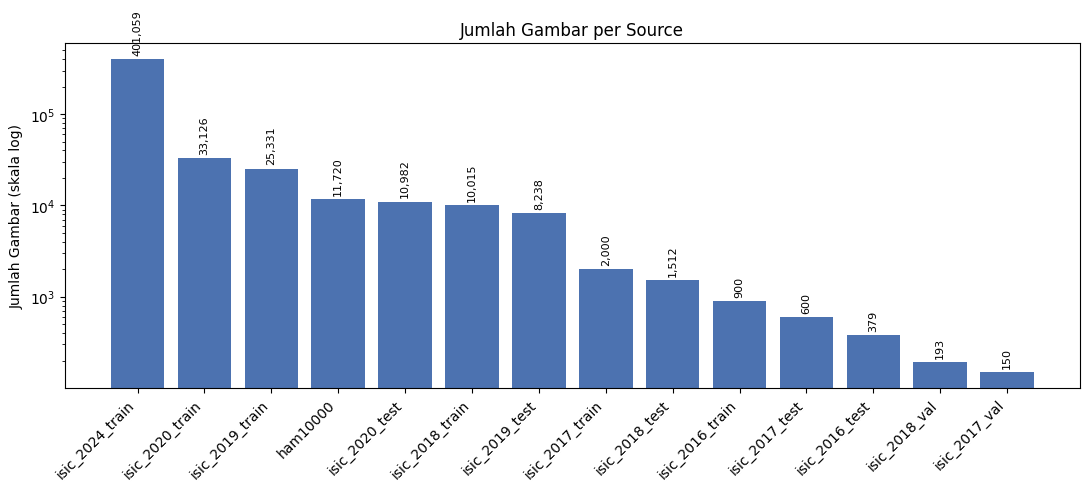

In [15]:
df_plot_desc = df_description.sort_values('Jumlah_Gambar', ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(df_plot_desc['Source'], df_plot_desc['Jumlah_Gambar'], color='#4C72B0')
ax.set_yscale('log')
ax.set_ylabel('Jumlah Gambar (skala log)')
ax.set_title('Jumlah Gambar per Source')
ax.bar_label(bars, labels=[f'{v:,}' for v in df_plot_desc['Jumlah_Gambar']],
             fontsize=8, rotation=90, padding=3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Fase 3 — Skema & Label

In [16]:
all_columns = sorted(set(col for df in metadata_dfs.values() for col in df.columns))
matrix_rows = []
for source, df_meta in metadata_dfs.items():
    row = {'Source': source}
    for col in all_columns:
        row[col] = '✓' if col in df_meta.columns else ''
    matrix_rows.append(row)

df_schema_matrix = pd.DataFrame(matrix_rows).set_index('Source')
df_schema_matrix

,acquisition_day,age_approx,anatom_site_1,anatom_site_2,anatom_site_3,anatom_site_4,anatom_site_5,anatom_site_special,attribution,clin_size_long_diam_mm,...,malignant,mel_mitotic_index,mel_thick_mm,mel_ulcer,melanocytic,patient_id,personal_hx_mm,pixels_x,pixels_y,sex
Source,,,,,,,,,,,,,,,,,,,,,
isic_2018_val,,✓,✓,✓,✓,,,✓,✓,,...,,,,,✓,,,✓,✓,✓
isic_2020_train,✓,✓,✓,✓,✓,,,✓,✓,✓,...,,✓,✓,✓,✓,✓,✓,✓,✓,✓
ham10000,,✓,✓,✓,✓,,,✓,✓,,...,,,,,✓,,,✓,✓,✓
isic_2019_train,,✓,✓,✓,✓,✓,✓,✓,✓,✓,...,,,,,✓,✓,✓,✓,✓,✓
isic_2016_test,,✓,✓,✓,✓,✓,✓,✓,✓,✓,...,,,,,✓,,✓,✓,✓,✓
isic_2018_test,,✓,✓,✓,✓,,,✓,✓,,...,,,,,✓,,,✓,✓,✓
isic_2019_test,,✓,✓,✓,✓,,,✓,✓,,...,,,,,✓,,,✓,✓,✓
isic_2020_test,✓,✓,✓,✓,✓,,,✓,✓,✓,...,,✓,✓,✓,✓,✓,✓,✓,✓,✓
isic_2018_train,,✓,✓,✓,✓,,,✓,✓,,...,,,,,✓,,,✓,✓,✓


In [17]:
class_count_summary = []
for source, df_meta in metadata_dfs.items():
    row = {'Source': source}
    for col in ['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'malignant']:
        if col in df_meta.columns:
            row[f'Kelas_unik_{col}'] = df_meta[col].nunique(dropna=True)
        else:
            row[f'Kelas_unik_{col}'] = '-'
    class_count_summary.append(row)

df_class_count = pd.DataFrame(class_count_summary)
df_class_count

,Source,Kelas_unik_diagnosis_1,Kelas_unik_diagnosis_2,Kelas_unik_diagnosis_3,Kelas_unik_malignant
0,isic_2018_val,2,7,6,-
1,isic_2020_train,3,9,16,-
2,ham10000,3,8,7,-
3,isic_2019_train,3,10,13,-
4,isic_2016_test,3,6,9,-
5,isic_2018_test,3,8,7,-
6,isic_2019_test,3,8,11,-
7,isic_2020_test,3,8,13,-
8,isic_2018_train,3,8,7,-
9,isic_2017_val,2,3,5,-


In [18]:
label_keywords = ['diagnos', 'benign_malignant', 'target', 'label', 'malignant']

for source, df_meta in metadata_dfs.items():
    candidate_cols = [c for c in df_meta.columns if any(k in c.lower() for k in label_keywords)]
    print(f"=== {source} ===")
    if not candidate_cols:
        print("  (gak ada kolom yang cocok)")
    for col in candidate_cols:
        print(f"  '{col}':")
        print(df_meta[col].value_counts().head(10).to_string())
    print()

=== isic_2018_val ===
  'diagnosis_1':
diagnosis_1
Benign       149
Malignant     44
  'diagnosis_2':
diagnosis_2
Benign melanocytic proliferations                           123
Benign epidermal proliferations                              22
Malignant melanocytic proliferations (Melanoma)              21
Malignant adnexal epithelial proliferations - Follicular     15
Malignant epidermal proliferations                            8
Benign soft tissue proliferations - Vascular                  3
Benign soft tissue proliferations - Fibro-histiocytic         1
  'diagnosis_3':
diagnosis_3
Nevus                           123
Pigmented benign keratosis       22
Melanoma, NOS                    21
Basal cell carcinoma             15
Squamous cell carcinoma, NOS      8
Dermatofibroma                    1
  'diagnosis_confirm_type':
diagnosis_confirm_type
histopathology                                   101
serial imaging showing no change                  76
single image expert consensus       

## Fase 4 — Eksplorasi Data (EDA)

In [19]:
DIAGNOSIS_COLUMN_MAP = {
    source: 'diagnosis_1'
    for source in metadata_dfs.keys()
    if 'diagnosis_1' in metadata_dfs[source].columns
}

print("Gak punya kolom diagnosis_1 (skema beda, dicek terpisah):",
      [s for s in metadata_dfs if s not in DIAGNOSIS_COLUMN_MAP])
DIAGNOSIS_COLUMN_MAP

Gak punya kolom diagnosis_1 (skema beda, dicek terpisah): ['isic_2024_train']


{'isic_2018_val': 'diagnosis_1',
 'isic_2020_train': 'diagnosis_1',
 'ham10000': 'diagnosis_1',
 'isic_2019_train': 'diagnosis_1',
 'isic_2016_test': 'diagnosis_1',
 'isic_2018_test': 'diagnosis_1',
 'isic_2019_test': 'diagnosis_1',
 'isic_2020_test': 'diagnosis_1',
 'isic_2018_train': 'diagnosis_1',
 'isic_2017_val': 'diagnosis_1',
 'isic_2017_test': 'diagnosis_1',
 'isic_2016_train': 'diagnosis_1',
 'isic_2017_train': 'diagnosis_1'}

In [20]:
class_dist_metadata = []
for source, col in DIAGNOSIS_COLUMN_MAP.items():
    counts = metadata_dfs[source][col].value_counts()
    for label, count in counts.items():
        class_dist_metadata.append({'Source': source, 'Label': label, 'Jumlah': count})

df_class_metadata = pd.DataFrame(class_dist_metadata)
df_class_pivot = df_class_metadata.pivot(index='Source', columns='Label', values='Jumlah').fillna(0).astype(int)
df_class_pivot

Label,Benign,Indeterminate,Malignant
Source,,,
ham10000,9415,149,2156
isic_2016_test,304,2,73
isic_2016_train,719,4,176
isic_2017_test,483,0,117
isic_2017_train,1625,1,374
isic_2017_val,120,0,30
isic_2018_test,1205,19,288
isic_2018_train,8061,130,1824
isic_2018_val,149,0,44


**Rasio malignant per source**

In [21]:
df_imbalance = df_class_pivot.copy()
df_imbalance['Total'] = df_imbalance.sum(axis=1)
for col in ['Benign', 'Malignant', 'Indeterminate']:
    if col in df_imbalance.columns:
        df_imbalance[f'Persen_{col}'] = (df_imbalance[col] / df_imbalance['Total'] * 100).round(2)

df_imbalance.sort_values('Persen_Malignant', ascending=False)


Label,Benign,Indeterminate,Malignant,Total,Persen_Benign,Persen_Malignant,Persen_Indeterminate
Source,,,,,,,
isic_2019_test,3606,370,3106,7082,50.92,43.86,5.22
isic_2019_train,15990,868,8473,25331,63.12,33.45,3.43
isic_2018_val,149,0,44,193,77.20,22.80,0.00
isic_2017_val,120,0,30,150,80.00,20.00,0.00
isic_2016_train,719,4,176,899,79.98,19.58,0.44
isic_2017_test,483,0,117,600,80.50,19.50,0.00
isic_2016_test,304,2,73,379,80.21,19.26,0.53
isic_2018_test,1205,19,288,1512,79.70,19.05,1.26
isic_2017_train,1625,1,374,2000,81.25,18.70,0.05


**Persen malignant ISIC 2024** (skema label beda, dihitung terpisah)

In [22]:
if 'isic_2024_train' in metadata_dfs:
    total_2024 = len(metadata_dfs['isic_2024_train'])
    malignant_2024 = metadata_dfs['isic_2024_train']['malignant'].sum()
    print(f"ISIC 2024 — persen malignant: {malignant_2024/total_2024*100:.2f}% ({int(malignant_2024)}/{total_2024})")


ISIC 2024 — persen malignant: 0.10% (393/401059)


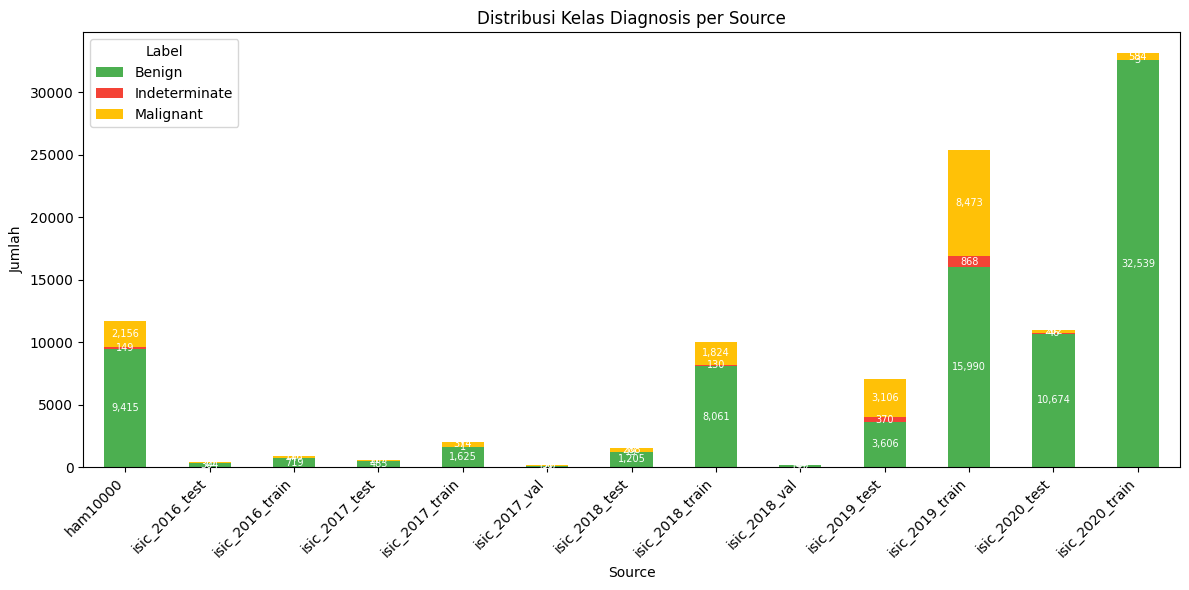

In [23]:
ax = df_class_pivot.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#4CAF50', '#F44336', '#FFC107'])
for container in ax.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=7, color='white')
plt.title('Distribusi Kelas Diagnosis per Source')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`isic_2024_train` gak ikut grafik di atas (skema beda). Isi label-nya sendiri:

In [24]:
if 'isic_2024_train' in metadata_dfs and 'malignant' in metadata_dfs['isic_2024_train'].columns:
    print(metadata_dfs['isic_2024_train']['malignant'].value_counts())

malignant
0.0    400666
1.0       393
Name: count, dtype: int64


In [25]:
demo_cols = {'Usia': 'age_approx', 'Jenis_Kelamin': 'sex', 'Lokasi_Anatomi_Utama': 'anatom_site_1'}

demo_rows = []
for source, df_meta in metadata_dfs.items():
    row = {'Source': source, 'Jumlah_Baris': len(df_meta)}
    for label, col in demo_cols.items():
        if col in df_meta.columns:
            row[f'{label}_Persen_Terisi'] = round(df_meta[col].notna().mean() * 100, 1)
        else:
            row[f'{label}_Persen_Terisi'] = 'Kolom tidak ada'
    demo_rows.append(row)

df_demo = pd.DataFrame(demo_rows)
df_demo

,Source,Jumlah_Baris,Usia_Persen_Terisi,Jenis_Kelamin_Persen_Terisi,Lokasi_Anatomi_Utama_Persen_Terisi
0,isic_2018_val,193,99.5,99.5,97.4
1,isic_2020_train,33126,99.8,99.8,89.2
2,ham10000,11720,96.7,97.1,95.0
3,isic_2019_train,25331,98.1,98.5,93.6
4,isic_2016_test,379,84.4,85.0,78.9
5,isic_2018_test,1512,81.0,80.5,77.8
6,isic_2019_test,8238,96.0,95.9,90.4
7,isic_2020_test,10982,100.0,100.0,89.4
8,isic_2018_train,10015,99.1,99.5,97.6
9,isic_2017_val,150,99.3,99.3,56.0


**Distribusi usia** (gabungan semua source mentah)

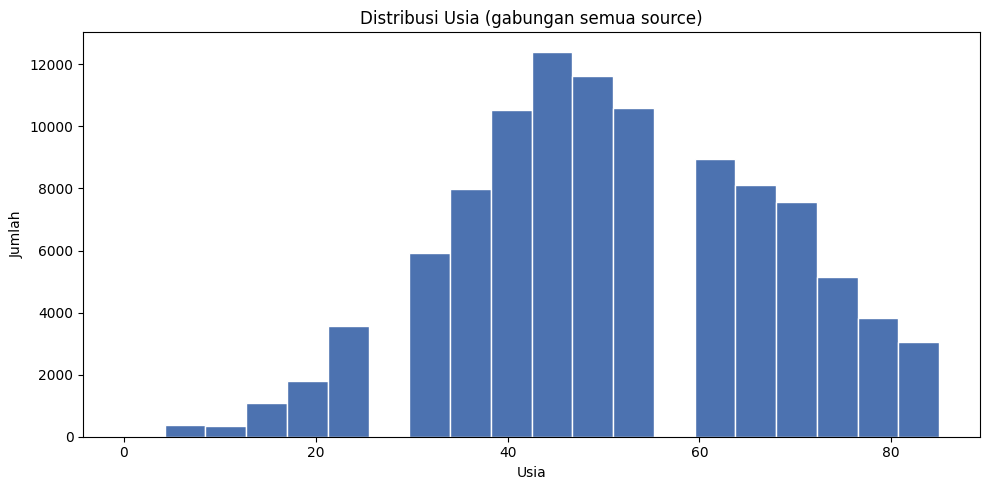

In [26]:
age_rows = [age for df in metadata_dfs.values() if 'age_approx' in df.columns for age in df['age_approx'].dropna()]
plt.figure(figsize=(10, 5))
plt.hist(age_rows, bins=20, color='#4C72B0', edgecolor='white')
plt.title('Distribusi Usia (gabungan semua source)')
plt.xlabel('Usia'); plt.ylabel('Jumlah')
plt.tight_layout(); plt.show()


**Distribusi jenis kelamin** (gabungan semua source mentah)

In [27]:
sex_rows = [s for df in metadata_dfs.values() if 'sex' in df.columns for s in df['sex'].dropna()]
print(pd.Series(sex_rows).value_counts())
print((pd.Series(sex_rows).value_counts(normalize=True) * 100).round(1))


male      54933
female    48264
Name: count, dtype: int64
male      53.2
female    46.8
Name: proportion, dtype: float64


**Distribusi lokasi anatomi** (gabungan semua source, top 15)

In [28]:
site_rows = [s for df in metadata_dfs.values() if 'anatom_site_1' in df.columns for s in df['anatom_site_1'].dropna()]
pd.Series(site_rows).value_counts().head(15)


Trunk                46584
Lower extremity      23775
Upper extremity      13508
Head and neck        11763
Anogenital region      174
Name: count, dtype: int64

## Fase 5 — Missing Values & Gambar Corrupt

In [29]:
missing_rows = []
for source, df_meta in metadata_dfs.items():
    for col in df_meta.columns:
        pct_missing = df_meta[col].isna().mean() * 100
        if pct_missing > 0:
            missing_rows.append({'Source': source, 'Kolom': col, 'Persen_Missing': round(pct_missing, 2)})

df_missing = pd.DataFrame(missing_rows).sort_values('Persen_Missing', ascending=False)
df_missing.head(30)

,Source,Kolom,Persen_Missing
22,isic_2020_train,mel_mitotic_index,100.00
23,isic_2020_train,mel_thick_mm,100.00
24,isic_2020_train,mel_ulcer,99.99
34,ham10000,image_manipulation,99.99
90,isic_2019_test,image_manipulation,99.99
78,isic_2018_test,image_manipulation,99.93
18,isic_2020_train,diagnosis_5,99.89
42,isic_2019_train,anatom_site_5,99.85
154,isic_2016_train,anatom_site_5,99.78
104,isic_2020_test,diagnosis_5,99.77


In [30]:
corrupt_files = []
for source, group in df_images.groupby('source'):
    print(f"Mengecek {source} ({len(group)} gambar)...")
    for fp in tqdm(group['filepath']):
        try:
            with Image.open(fp) as img:
                img.verify()
        except Exception as e:
            corrupt_files.append({'source': source, 'filepath': fp, 'error': str(e)})

df_corrupt = pd.DataFrame(corrupt_files)
print(f"\nTotal gambar corrupt: {len(df_corrupt)}")
df_corrupt

Mengecek ham10000 (11720 gambar)...


100%|██████████| 11720/11720 [00:42<00:00, 272.81it/s]


Mengecek isic_2016_test (379 gambar)...


100%|██████████| 379/379 [00:01<00:00, 327.20it/s]


Mengecek isic_2016_train (900 gambar)...


...

100%|██████████| 33126/33126 [03:21<00:00, 164.38it/s]


Mengecek isic_2024_train (401059 gambar)...


100%|██████████| 401059/401059 [32:23<00:00, 206.39it/s]


Total gambar corrupt: 0


""


## Fase 6 — Deteksi Duplikat

In [31]:
label_lookup = {}
for source, df_meta in metadata_dfs.items():
    if 'diagnosis_1' in df_meta.columns and 'isic_id' in df_meta.columns:
        for _, r in df_meta[['isic_id', 'diagnosis_1']].iterrows():
            label_lookup[r['isic_id']] = r['diagnosis_1']

df_images['diagnosis_1'] = df_images['image_id'].map(label_lookup)
print(f"Gambar dengan label: {df_images['diagnosis_1'].notna().sum()} / {len(df_images)}")

Gambar dengan label: 103989 / 506205


In [32]:
dup_check = df_images.groupby('image_id')['source'].apply(lambda x: list(x.unique())).reset_index()
dup_check['jumlah_source'] = dup_check['source'].apply(len)

df_duplicates = dup_check[dup_check['jumlah_source'] > 1].sort_values('jumlah_source', ascending=False)
print(f"Image ID yang muncul di >1 source: {len(df_duplicates)}")
df_duplicates.head(20)

Image ID yang muncul di >1 source: 14623


,image_id,source,jumlah_source
14701,ISIC_0036064,"[ham10000, isic_2018_test, isic_2019_test]",3
0,ISIC_0000000,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
1,ISIC_0000001,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
2,ISIC_0000002,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
3,ISIC_0000003,"[isic_2019_train, isic_2016_test, isic_2017_tr...",3
4,ISIC_0000004,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
5,ISIC_0000006,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
6,ISIC_0000007,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
7,ISIC_0000008,"[isic_2019_train, isic_2016_train, isic_2017_t...",3
8,ISIC_0000009,"[isic_2019_train, isic_2016_train, isic_2017_t...",3


**Cek label konsisten** untuk gambar yang sama muncul di banyak source

In [33]:
label_dict = {}
for src, df_meta in metadata_dfs.items():
    if 'diagnosis_1' in df_meta.columns and 'isic_id' in df_meta.columns:
        for iid, lab in zip(df_meta['isic_id'], df_meta['diagnosis_1']):
            label_dict[(src, iid)] = lab

label_check_rows = []
for _, row in df_duplicates.iterrows():
    image_id = row['image_id']
    labels_per_source = {src: label_dict.get((src, image_id)) for src in row['source']}
    unique_labels = set(v for v in labels_per_source.values() if v is not None)
    label_check_rows.append({
        'image_id': image_id,
        'labels_per_source': labels_per_source,
        'konsisten': len(unique_labels) <= 1
    })

df_label_consistency = pd.DataFrame(label_check_rows)
print(f"Dicek: {len(df_label_consistency)}, Konsisten: {df_label_consistency['konsisten'].sum()}, TIDAK konsisten: {(~df_label_consistency['konsisten']).sum()}")
df_label_consistency[~df_label_consistency['konsisten']].head(20)


Dicek: 14623, Konsisten: 14623, TIDAK konsisten: 0


,image_id,labels_per_source,konsisten


**Cek duplikat level lesi** (lesion_id) — beda lesi difoto berkali-kali, risiko bocor ke train/test

In [34]:
sources_dgn_lesion_id = [s for s, df in metadata_dfs.items() if 'lesion_id' in df.columns]
print("Source dengan lesion_id:", sources_dgn_lesion_id)

lesion_rows = []
for src in sources_dgn_lesion_id:
    df_meta = metadata_dfs[src]
    for lid, iid in zip(df_meta['lesion_id'], df_meta['isic_id']):
        if pd.notna(lid):
            lesion_rows.append({'lesion_id': lid, 'image_id': iid, 'source': src})

df_lesion = pd.DataFrame(lesion_rows)
lesion_counts = df_lesion.groupby('lesion_id')['image_id'].nunique().sort_values(ascending=False)
print(f"Lesi unik: {len(lesion_counts)}, Lesi dengan >1 gambar: {(lesion_counts > 1).sum()}")

lesion_source_spread = df_lesion.groupby('lesion_id')['source'].apply(lambda x: sorted(set(x)))
multi_source_lesions = lesion_source_spread[lesion_source_spread.apply(len) > 1]
print(f"Lesi yang gambarnya tersebar di >1 source: {len(multi_source_lesions)}")
multi_source_lesions.head(10)


Source dengan lesion_id: ['isic_2018_val', 'isic_2020_train', 'ham10000', 'isic_2019_train', 'isic_2018_test', 'isic_2019_test', 'isic_2020_test', 'isic_2018_train', 'isic_2017_val', 'isic_2017_test', 'isic_2017_train']
Lesi unik: 59084, Lesi dengan >1 gambar: 7381
Lesi yang gambarnya tersebar di >1 source: 10056


lesion_id
IL_0000128    [ham10000, isic_2018_train, isic_2019_train]
IL_0000561              [isic_2017_train, isic_2019_train]
IL_0000732    [ham10000, isic_2018_train, isic_2019_train]
IL_0000798    [ham10000, isic_2018_train, isic_2019_train]
IL_0001105    [ham10000, isic_2018_train, isic_2019_train]
IL_0003174    [ham10000, isic_2018_train, isic_2019_train]
IL_0003295    [ham10000, isic_2018_train, isic_2019_train]
IL_0003422    [ham10000, isic_2018_train, isic_2019_train]
IL_0005012      [ham10000, isic_2018_test, isic_2019_test]
IL_0005158      [ham10000, isic_2018_test, isic_2019_test]
Name: source, dtype: object

**Cross-check ke daftar duplikat resmi ISIC 2020** — isi `official_dup_path` setelah file diupload

In [40]:
official_dup_path = '/kaggle/input/datasets/nadiraanindita/isic-2020-training-duplicates/ISIC_2020_Training_Duplicates.csv'

df_official_dup = pd.read_csv(official_dup_path)

if 'isic_2020_train' in metadata_dfs and 'lesion_id' in metadata_dfs['isic_2020_train'].columns:
    lesion_map_2020 = metadata_dfs['isic_2020_train'].set_index('isic_id')['lesion_id'].to_dict()

    match_rows = []
    for _, row in df_official_dup.iterrows():
        id1, id2 = row['image_name_1'], row['image_name_2']
        l1, l2 = lesion_map_2020.get(id1), lesion_map_2020.get(id2)
        match_rows.append({
            'image_name_1': id1, 'image_name_2': id2,
            'lesion_id_1': l1, 'lesion_id_2': l2,
            'lesion_id_sama': (l1 == l2) if (l1 and l2) else None
        })

    df_cross_check = pd.DataFrame(match_rows)
    print(f"Total pasangan resmi: {len(df_cross_check)}")
    print(f"Lesion_id cocok (validasi silang OK): {df_cross_check['lesion_id_sama'].sum()}")
    df_cross_check.head(10)

Total pasangan resmi: 425
Lesion_id cocok (validasi silang OK): 417


In [41]:
ids_2020 = set(df_images[df_images['source'] == 'isic_2020_train']['image_id'])
found_both = df_official_dup.apply(lambda r: r['image_name_1'] in ids_2020 and r['image_name_2'] in ids_2020, axis=1)
print(f"Pasangan yang ketemu di data kita: {found_both.sum()} / {len(df_official_dup)}")

Pasangan yang ketemu di data kita: 425 / 425


In [42]:
pair_counter = Counter()
for src_list in df_duplicates['source']:
    for a, b in combinations(sorted(set(src_list)), 2):
        pair_counter[(a, b)] += 1

df_pairs = pd.DataFrame(pair_counter.items(), columns=['Pasangan_Source', 'Jumlah_Overlap'])
df_pairs = df_pairs.sort_values('Jumlah_Overlap', ascending=False)
df_pairs

,Pasangan_Source,Jumlah_Overlap
14,"(isic_2018_train, isic_2019_train)",10015
12,"(ham10000, isic_2018_train)",10015
13,"(ham10000, isic_2019_train)",10015
5,"(isic_2017_train, isic_2019_train)",2000
1,"(ham10000, isic_2019_test)",1705
2,"(isic_2018_test, isic_2019_test)",1512
0,"(ham10000, isic_2018_test)",1512
4,"(isic_2016_train, isic_2019_train)",859
3,"(isic_2016_train, isic_2017_train)",746
15,"(isic_2017_test, isic_2019_train)",595


In [43]:
# Lesi dengan lebih dari 1 image_id BERBEDA (bukan sekadar ID yang sama nempel di banyak folder)
lesion_multi_image = lesion_counts[lesion_counts > 1].index

# Dari situ, cek mana yang juga tersebar ke lebih dari 1 source
risiko_asli = lesion_source_spread[
    lesion_source_spread.index.isin(lesion_multi_image) & (lesion_source_spread.apply(len) > 1)
]
print(f"Lesi dengan foto BERBEDA ID yang tersebar ke banyak source (risiko nyata): {len(risiko_asli)}")
risiko_asli.head(10)

Lesi dengan foto BERBEDA ID yang tersebar ke banyak source (risiko nyata): 2236


lesion_id
IL_0000128    [ham10000, isic_2018_train, isic_2019_train]
IL_0001105    [ham10000, isic_2018_train, isic_2019_train]
IL_0003422    [ham10000, isic_2018_train, isic_2019_train]
IL_0019655    [ham10000, isic_2018_train, isic_2019_train]
IL_0029722    [ham10000, isic_2018_train, isic_2019_train]
IL_0037536    [ham10000, isic_2018_train, isic_2019_train]
IL_0041758    [ham10000, isic_2018_train, isic_2019_train]
IL_0042893    [ham10000, isic_2018_train, isic_2019_train]
IL_0045364    [ham10000, isic_2018_train, isic_2019_train]
IL_0047878    [ham10000, isic_2018_train, isic_2019_train]
Name: source, dtype: object

## Fase 7 — Data Bersih & Before/After

In [44]:
corrupt_filepaths = set(df_corrupt['filepath']) if len(df_corrupt) > 0 else set()

df_no_corrupt = df_images[~df_images['filepath'].isin(corrupt_filepaths)]
df_clean = df_no_corrupt.drop_duplicates(subset=['image_id'], keep='first')

print(f"Awal: {len(df_images):,}")
print(f"Setelah hapus corrupt: {len(df_no_corrupt):,}")
print(f"Setelah hapus duplikat: {len(df_clean):,}")

Awal: 506,205
Setelah hapus corrupt: 506,205
Setelah hapus duplikat: 478,808


In [46]:
before_counts = df_images.groupby('source').size().rename('Jumlah_Awal')
corrupt_counts = (df_corrupt.groupby('source').size().rename('Corrupt_Dihapus')
                   if len(df_corrupt) > 0 else pd.Series(dtype=int, name='Corrupt_Dihapus'))
after_counts = df_clean.groupby('source').size().rename('Jumlah_Setelah_Bersih')

df_comparison = pd.concat([before_counts, corrupt_counts, after_counts], axis=1).fillna(0).astype(int)
df_comparison['Duplikat_Dihapus'] = (df_comparison['Jumlah_Awal']
                                      - df_comparison['Corrupt_Dihapus']
                                      - df_comparison['Jumlah_Setelah_Bersih'])
df_comparison = df_comparison.reset_index().rename(columns={'index': 'Dataset'})
df_comparison = df_comparison[['Dataset', 'Jumlah_Awal', 'Corrupt_Dihapus', 'Duplikat_Dihapus', 'Jumlah_Setelah_Bersih']]

total_row = pd.DataFrame([{
    'Dataset': 'TOTAL',
    'Jumlah_Awal': df_comparison['Jumlah_Awal'].sum(),
    'Corrupt_Dihapus': df_comparison['Corrupt_Dihapus'].sum(),
    'Duplikat_Dihapus': df_comparison['Duplikat_Dihapus'].sum(),
    'Jumlah_Setelah_Bersih': df_comparison['Jumlah_Setelah_Bersih'].sum()
}])
df_comparison_final = pd.concat([df_comparison, total_row], ignore_index=True)
df_comparison_final

,Dataset,Jumlah_Awal,Corrupt_Dihapus,Duplikat_Dihapus,Jumlah_Setelah_Bersih
0,ham10000,11720,0,193,11527
1,isic_2016_test,379,0,353,26
2,isic_2016_train,900,0,859,41
3,isic_2017_test,600,0,595,5
4,isic_2017_train,2000,0,2000,0
5,isic_2017_val,150,0,150,0
6,isic_2018_test,1512,0,1512,0
7,isic_2018_train,10015,0,10015,0
8,isic_2018_val,193,0,0,193
9,isic_2019_test,8238,0,1705,6533


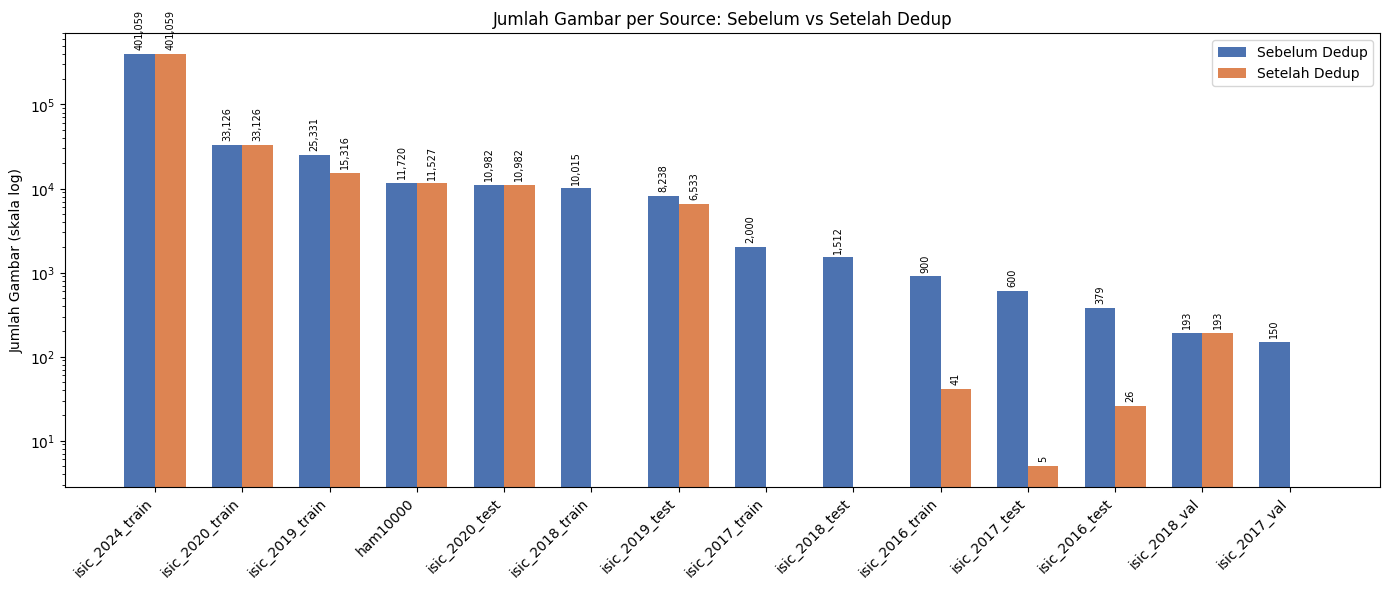

In [47]:
import numpy as np

df_plot = df_comparison_final[df_comparison_final['Dataset'] != 'TOTAL'].sort_values('Jumlah_Awal', ascending=False)
x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bar1 = ax.bar(x - width/2, df_plot['Jumlah_Awal'], width, label='Sebelum Dedup', color='#4C72B0')
bar2 = ax.bar(x + width/2, df_plot['Jumlah_Setelah_Bersih'], width, label='Setelah Dedup', color='#DD8452')

ax.set_yscale('log')
ax.set_ylabel('Jumlah Gambar (skala log)')
ax.set_title('Jumlah Gambar per Source: Sebelum vs Setelah Dedup')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Dataset'], rotation=45, ha='right')
ax.legend()
for bars in [bar1, bar2]:
    labels = [f'{int(v):,}' for v in bars.datavalues]
    ax.bar_label(bars, labels=labels, fontsize=7, rotation=90, padding=3)

plt.tight_layout()
plt.show()

## Fase 8 — Simpan Output

In [48]:
OUTPUT_DIR = '/kaggle/working'

df_clean.to_csv(f'{OUTPUT_DIR}/data_bersih_gabungan.csv', index=False)
df_comparison_final.to_csv(f'{OUTPUT_DIR}/tabel_perbandingan_before_after.csv', index=False)
df_description.to_csv(f'{OUTPUT_DIR}/deskripsi_dataset.csv', index=False)
df_schema_matrix.to_csv(f'{OUTPUT_DIR}/matriks_skema_kolom.csv')
df_missing.to_csv(f'{OUTPUT_DIR}/laporan_missing_values.csv', index=False)
status_final.to_csv(f'{OUTPUT_DIR}/laporan_verifikasi_data.csv', index=False)
if len(df_corrupt) > 0:
    df_corrupt.to_csv(f'{OUTPUT_DIR}/laporan_gambar_corrupt.csv', index=False)

print("Tersimpan di /kaggle/working.")
print(f"Source yang belum masuk analisis ini: {sources_belum_siap}")

Tersimpan di /kaggle/working.
Source yang belum masuk analisis ini: []
